# Linear and Logistic Models: From Manual Gradient Descent to TensorFlow

This notebook connects hand-coded optimization to framework-based model training using MNIST.

The first part treats digit **5** as the positive class and all other digits as the negative
class. Linear and logistic classifiers are trained directly with gradient descent and compared
with scikit-learn. The second part extends the problem to ten-class MNIST classification with
TensorFlow/Keras and explores different features, activations, losses, and optimizers.

## 1. Binary MNIST Classification from Scratch

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import time

### 1.1 Load and preprocess MNIST

Images are flattened and scaled to `[0, 1]`. The binary target is **digit 5 vs. all other digits**.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train = np.hstack((x_train,np.ones((x_train.shape[0],1))))
x_test = np.hstack((x_test,np.ones((x_test.shape[0],1))))

target_class = 5
y_train  = (y_train==target_class).astype(int)
y_test  = (y_test==target_class).astype(int)

### 1.2 Linear model with a classification threshold

Epoch: 10/100, mse = 0.071698, accuracy = 0.9103
Epoch: 20/100, mse = 0.063186, accuracy = 0.9149
Epoch: 30/100, mse = 0.059301, accuracy = 0.9193
Epoch: 40/100, mse = 0.057167, accuracy = 0.9224
Epoch: 50/100, mse = 0.055828, accuracy = 0.9252
Epoch: 60/100, mse = 0.054893, accuracy = 0.9273
Epoch: 70/100, mse = 0.054187, accuracy = 0.9290
Epoch: 80/100, mse = 0.053622, accuracy = 0.9304
Epoch: 90/100, mse = 0.053153, accuracy = 0.9312
Epoch: 100/100, mse = 0.052753, accuracy = 0.9321
Accuracy 0.9381
[[9093   15]
 [ 604  288]]


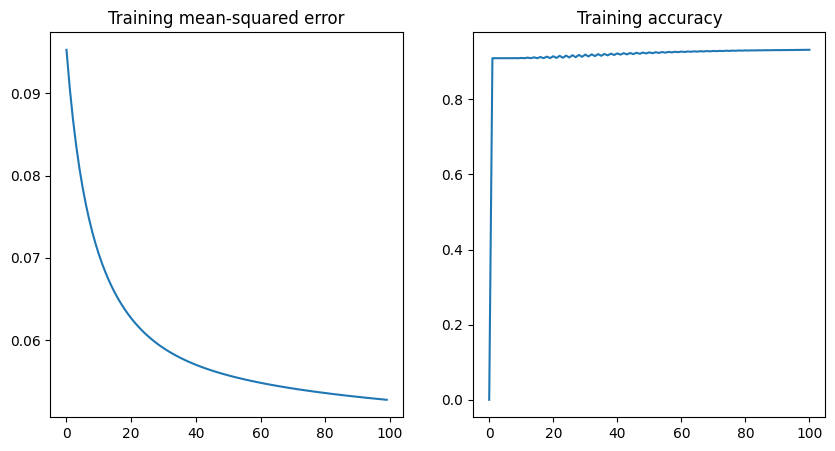

In [4]:
def linear_regression_gd(X,y,lr=0.01, tol =0.001,max_it = 1000,display_period=10):
    # It will return w that minimizes (Xw - y)**2
    # It will exit when the mean squard error is less than tol or the number of iterations reaches max_it
    acc_list, mse_list = [], []
    n, m = X.shape                  # the training set has n examples and m attributes
    w =  (np.random.random((1,m))-.5)*.01      # w is 1xm
    for i in range(1,max_it+1):
        pred = np.sum(X*w, axis =1)          # pred has len n
        error = (pred - y).reshape(-1,1)     # error is nx1
        mse_train = np.mean(error**2)              # mse is a scalar
        mse_list.append(mse_train)
        pred_class = (pred>1/2).astype(int)
        acc = accuracy_score(y,pred_class)
        acc_list.append(acc)
        if mse_train<tol:
            break
        gradient = np.mean(X*error,axis=0)   # gradient is 1xm
        w = w - lr*gradient
        if i%display_period==0:
            print('Epoch: {}/{}, mse = {:.6f}, accuracy = {:.4f}'.format(i,max_it,mse_train,acc))
            #print('Epoch: {}/{}, mse = {:.6f}'.format(i,max_it,mse))
    fig, ax = plt.subplots(1,2,figsize=(10,5))
    ax[0].plot(mse_list)
    ax[0].set_title('Training mean-squared error')
    ax[1].plot([0]+acc_list)
    ax[1].set_title('Training accuracy')
    return w


w = linear_regression_gd(x_train,y_train,lr=0.05,max_it = 100)

pred = np.sum(x_test*w, axis =1)
pred_class = (pred>1/2).astype(int)

accuracy = accuracy_score(y_test, pred_class)
print(f'Accuracy {accuracy:.4}')
print(confusion_matrix(y_test, pred_class))


### 1.3 Logistic regression with sigmoid activation

The sigmoid output provides a bounded score for binary classification while preserving the
same gradient-descent training principle.

Epoch: 10/1000, mse = 0.082455, accuracy = 0.9096
Epoch: 20/1000, mse = 0.078804, accuracy = 0.9096
Epoch: 30/1000, mse = 0.074671, accuracy = 0.9096
Epoch: 40/1000, mse = 0.070009, accuracy = 0.9096
Epoch: 50/1000, mse = 0.065489, accuracy = 0.9101
Epoch: 60/1000, mse = 0.061514, accuracy = 0.9138
Epoch: 70/1000, mse = 0.058174, accuracy = 0.9204
Epoch: 80/1000, mse = 0.055406, accuracy = 0.9271
Epoch: 90/1000, mse = 0.053105, accuracy = 0.9319
Epoch: 100/1000, mse = 0.051171, accuracy = 0.9358
Epoch: 110/1000, mse = 0.049526, accuracy = 0.9392
Epoch: 120/1000, mse = 0.048109, accuracy = 0.9421
Epoch: 130/1000, mse = 0.046874, accuracy = 0.9441
Epoch: 140/1000, mse = 0.045786, accuracy = 0.9459
Epoch: 150/1000, mse = 0.044819, accuracy = 0.9475
Epoch: 160/1000, mse = 0.043953, accuracy = 0.9490
Epoch: 170/1000, mse = 0.043170, accuracy = 0.9503
Epoch: 180/1000, mse = 0.042460, accuracy = 0.9513
Epoch: 190/1000, mse = 0.041811, accuracy = 0.9521
Epoch: 200/1000, mse = 0.041215, accurac

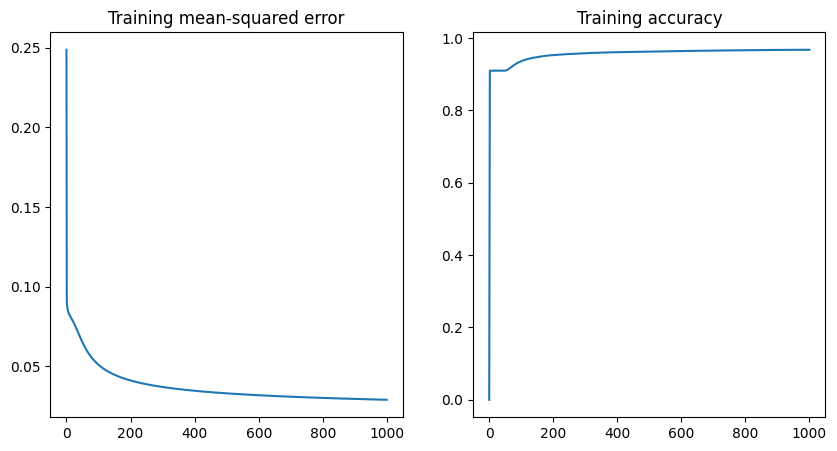

In [5]:
def sigma(X,w):
    z = np.sum(X*w, axis =1)
    return (1/(1+np.exp(-z)))

def logistic_regression_gd(X,y,lr=0.01, tol =0.001,max_it = 1000):
    n, m = X.shape         # the training set has n examples and m attributes
    w =  (np.random.random((1,m))-.5)*.01    # w is 1xm
    for i in range(1,max_it+1):
        s = sigma(X,w)          # s has len n
        error = (s - y)         # error is nx1
        if np.mean(error**2)<tol: break
        g = (error*s*(1-s)).reshape(-1,1)
        gradient = np.mean(X*g,axis=0)   # gradient is 1xm
        w = w - lr*gradient

        if i%display_period==0:
            print('Epoch: {}/{}, mse = {:.6f}, accuracy = {:.4f}'.format(i,max_it,mse_train,acc))
    return w


def logistic_regression_gd(X,y,lr=0.01, tol =0.001,max_it = 1000,display_period=10):
    # It will return w that minimizes (sigma(Xw) - y)**2
    # It will exit when the mean squard error is less than tol or the number of iterations reaches max_it
    acc_list, mse_list = [], []
    n, m = X.shape                  # the training set has n examples and m attributes
    w =  (np.random.random((1,m))-.5)*.1      # w is 1xm
    for i in range(1,max_it+1):
        s = sigma(X,w)          # s has len n
        error = (s - y)
        mse_train = np.mean(error**2)              # mse is a scalar
        mse_list.append(mse_train)

        pred_class = (s>1/2).astype(int)
        acc = accuracy_score((y>1/2).astype(int),pred_class)
        acc_list.append(acc)
        if mse_train<tol:
            break
        g = (error*s*(1-s)).reshape(-1,1)
        gradient = np.mean(X*g,axis=0)   # gradient is 1xm
        w = w - lr*gradient
        if i%display_period==0:
            print('Epoch: {}/{}, mse = {:.6f}, accuracy = {:.4f}'.format(i,max_it,mse_train,acc))
            #print('Epoch: {}/{}, mse = {:.6f}'.format(i,max_it,mse))
    fig, ax = plt.subplots(1,2,figsize=(10,5))
    ax[0].plot(mse_list)
    ax[0].set_title('Training mean-squared error')
    ax[1].plot([0]+acc_list)
    ax[1].set_title('Training accuracy')
    return w


w = logistic_regression_gd(x_train,y_train,lr=0.5,max_it = 1000)
pred = sigma(x_test,w)
pred_class = (pred>1/2).astype(int)
accuracy = accuracy_score(y_test, pred_class)
print(f'Accuracy {accuracy:.4}')
print(confusion_matrix(y_test, pred_class))



### 1.4 scikit-learn logistic-regression comparison

In [6]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=100,verbose=1,n_jobs=-1)
model.fit(x_train,y_train)
pred = model.predict(x_test)
accuracy = accuracy_score(y_test, pred)
print(f'Accuracy {accuracy:.4}')
print(confusion_matrix(y_test, pred))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Accuracy 0.9777
[[9040   68]
 [ 155  737]]


## 2. TensorFlow/Keras Multiclass Models

TensorFlow/Keras expresses models as sequences of linear and nonlinear operations,
computes gradients automatically, and provides multiple optimizers and loss functions.
The following experiments progressively modify the same MNIST classification setup.

### TensorFlow Setup

In [7]:
import tensorflow as tf
import numpy as np
import os
import distutils
import matplotlib.pyplot as plt
from keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
import time

### Training-Curve Utility

In [8]:
def plot_results(history):
  fig, ax = plt.subplots()
  ax.plot(history.history['accuracy'],label = 'train')
  ax.plot(history.history['val_accuracy'],label = 'test')
  ax.set_title('Accuracy')
  ax.legend(loc='lower right')
  fig, ax = plt.subplots()
  ax.plot(history.history['loss'],label = 'train')
  ax.plot(history.history['val_loss'],label = 'test')
  ax.set_title('Loss')
  ax.legend(loc='upper right')

### MNIST Preprocessing

In [9]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

## 2.1 Linear Multiclass Model

### Model Definition

In [10]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Dense(n_outputs, input_shape=(n_inputs,))) # A Dense layer implements the function y = Wx + b
  return model

### Model Configuration

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

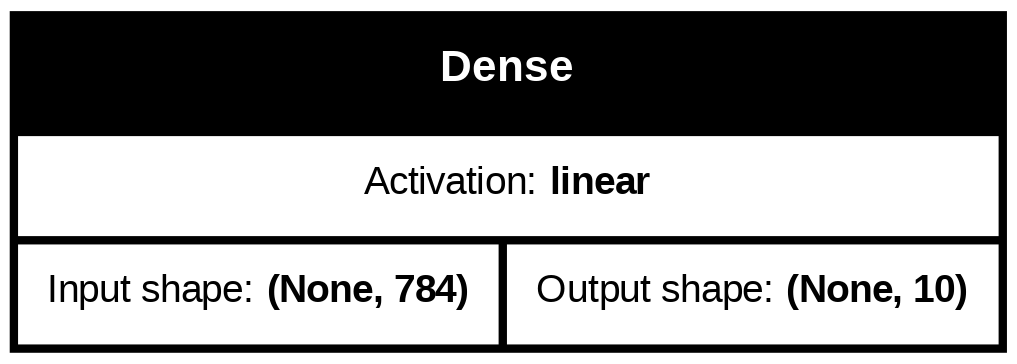

In [11]:
model = linear_regression(x_train.shape[1], y_train.shape[1])  # Create model with 784 inputs and 10 outputs
model.summary()                                                # Show model structure
opt = tf.keras.optimizers.SGD(learning_rate=0.01)              # Create
model.compile(optimizer=opt, loss="mse", metrics=["accuracy"]) # Specify optimizer and loss function
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True) # Graphical depiction of model

### Model Training and Evaluation

Epoch 1/40
600/600 - 3s - 5ms/step - accuracy: 0.4228 - loss: 0.1186 - val_accuracy: 0.6202 - val_loss: 0.0813
Epoch 2/40
600/600 - 2s - 3ms/step - accuracy: 0.6633 - loss: 0.0741 - val_accuracy: 0.7163 - val_loss: 0.0662
Epoch 3/40
600/600 - 1s - 2ms/step - accuracy: 0.7243 - loss: 0.0643 - val_accuracy: 0.7537 - val_loss: 0.0600
Epoch 4/40
600/600 - 2s - 3ms/step - accuracy: 0.7543 - loss: 0.0595 - val_accuracy: 0.7768 - val_loss: 0.0563
Epoch 5/40
600/600 - 1s - 2ms/step - accuracy: 0.7724 - loss: 0.0565 - val_accuracy: 0.7920 - val_loss: 0.0540
Epoch 6/40
600/600 - 1s - 2ms/step - accuracy: 0.7855 - loss: 0.0543 - val_accuracy: 0.8021 - val_loss: 0.0522
Epoch 7/40
600/600 - 2s - 3ms/step - accuracy: 0.7941 - loss: 0.0527 - val_accuracy: 0.8088 - val_loss: 0.0508
Epoch 8/40
600/600 - 2s - 4ms/step - accuracy: 0.8014 - loss: 0.0514 - val_accuracy: 0.8142 - val_loss: 0.0497
Epoch 9/40
600/600 - 2s - 4ms/step - accuracy: 0.8065 - loss: 0.0504 - val_accuracy: 0.8186 - val_loss: 0.0488
E

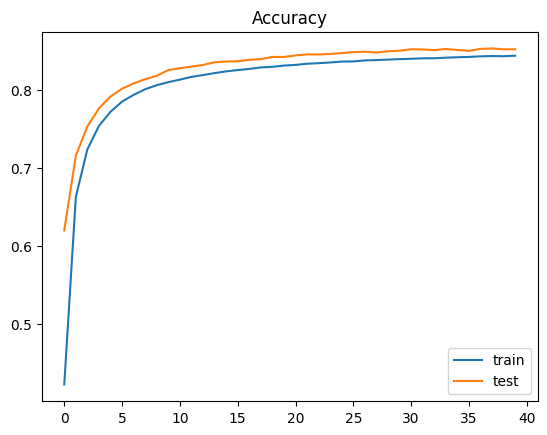

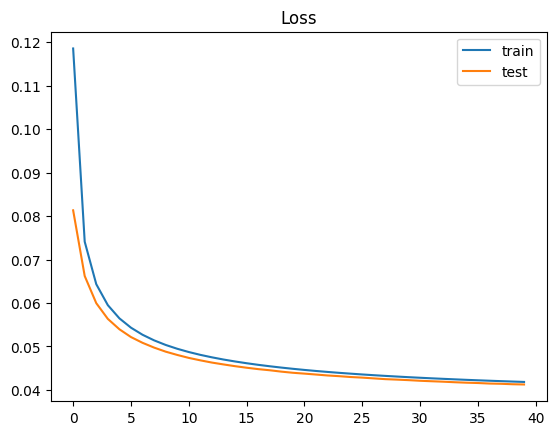

In [12]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 100,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(x_test, y_test), # If provided, allows to keep track of loss on validation data as traiing progresses
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))


### Quadratic Feature Expansion

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │        15,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,690 (61.29 KB)

 Trainable params: 15,690 (61.29 KB)

 Non-trainable params: 0 (0.00 B)

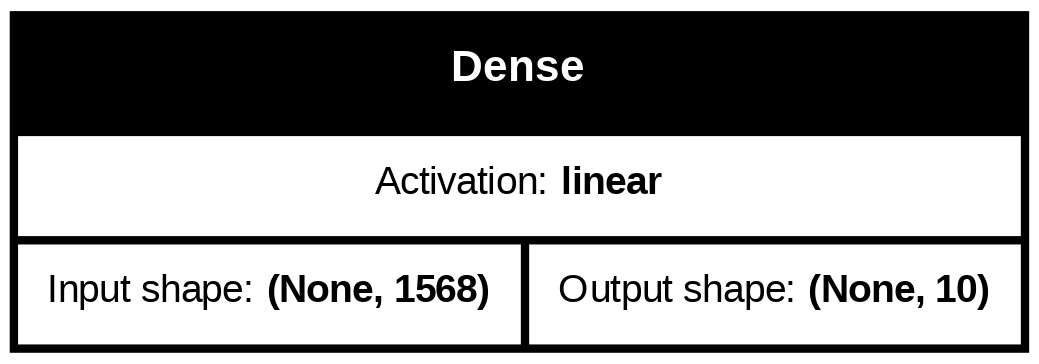

In [13]:
model = linear_regression(x_train.shape[1]*2, y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.01)
model.compile(optimizer=opt, loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
600/600 - 2s - 4ms/step - accuracy: 0.5515 - loss: 0.0957 - val_accuracy: 0.7180 - val_loss: 0.0686
Epoch 2/40
600/600 - 2s - 3ms/step - accuracy: 0.7378 - loss: 0.0639 - val_accuracy: 0.7723 - val_loss: 0.0586
Epoch 3/40
600/600 - 2s - 3ms/step - accuracy: 0.7747 - loss: 0.0574 - val_accuracy: 0.7937 - val_loss: 0.0544
Epoch 4/40
600/600 - 3s - 4ms/step - accuracy: 0.7925 - loss: 0.0539 - val_accuracy: 0.8084 - val_loss: 0.0518
Epoch 5/40
600/600 - 3s - 5ms/step - accuracy: 0.8032 - loss: 0.0517 - val_accuracy: 0.8166 - val_loss: 0.0500
Epoch 6/40
600/600 - 2s - 3ms/step - accuracy: 0.8112 - loss: 0.0501 - val_accuracy: 0.8221 - val_loss: 0.0485
Epoch 7/40
600/600 - 2s - 3ms/step - accuracy: 0.8175 - loss: 0.0488 - val_accuracy: 0.8297 - val_loss: 0.0475
Epoch 8/40
600/600 - 2s - 3ms/step - accuracy: 0.8211 - loss: 0.0478 - val_accuracy: 0.8331 - val_loss: 0.0466
Epoch 9/40
600/600 - 3s - 4ms/step - accuracy: 0.8263 - loss: 0.0469 - val_accuracy: 0.8336 - val_loss: 0.0459
E

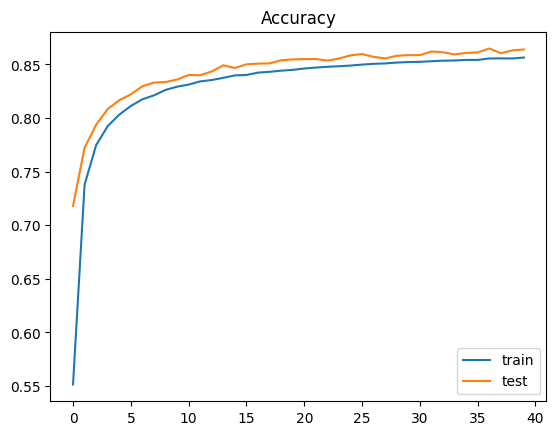

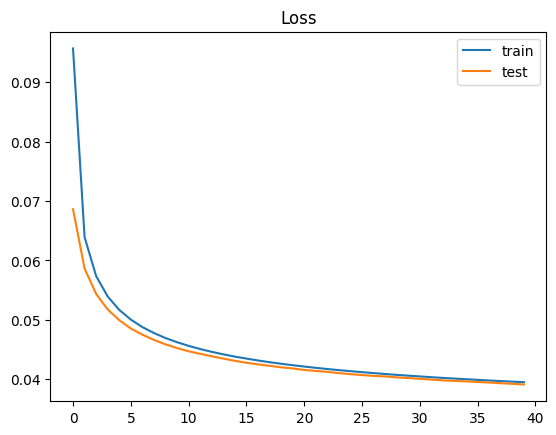

In [14]:
start_train = time.time()
history = model.fit(
    np.hstack((x_train,x_train**2)), y_train,
    epochs =  40,
    batch_size = 100,
    verbose = 2,
    validation_data=(np.hstack((x_test,x_test**2)), y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(np.hstack((x_test,x_test**2)))
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))



## 2.2 Sigmoid Logistic Model

In [15]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Dense(n_outputs, input_shape=(n_inputs,), activation='sigmoid'))
  return model

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

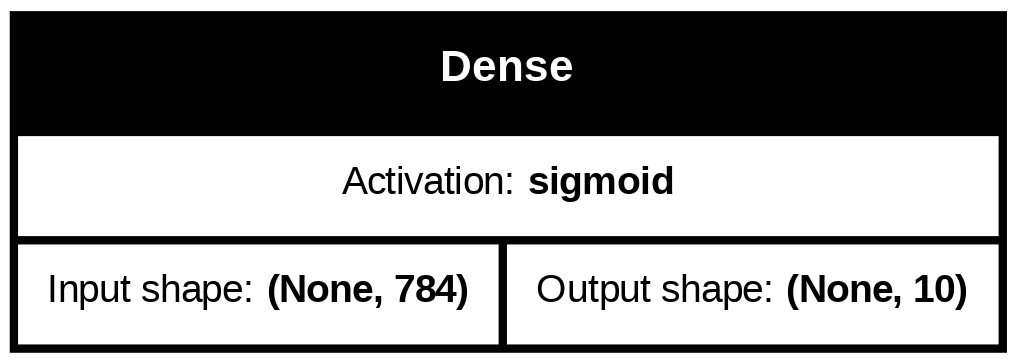

In [16]:
model = logistic_regression(x_train.shape[1], y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.2)
model.compile(optimizer=opt, loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
600/600 - 2s - 3ms/step - accuracy: 0.5986 - loss: 0.0689 - val_accuracy: 0.8019 - val_loss: 0.0482
Epoch 2/40
600/600 - 3s - 4ms/step - accuracy: 0.8223 - loss: 0.0428 - val_accuracy: 0.8519 - val_loss: 0.0373
Epoch 3/40
600/600 - 4s - 6ms/step - accuracy: 0.8477 - loss: 0.0357 - val_accuracy: 0.8654 - val_loss: 0.0327
Epoch 4/40
600/600 - 3s - 4ms/step - accuracy: 0.8585 - loss: 0.0323 - val_accuracy: 0.8733 - val_loss: 0.0301
Epoch 5/40
600/600 - 4s - 7ms/step - accuracy: 0.8648 - loss: 0.0301 - val_accuracy: 0.8788 - val_loss: 0.0284
Epoch 6/40
600/600 - 1s - 2ms/step - accuracy: 0.8698 - loss: 0.0287 - val_accuracy: 0.8827 - val_loss: 0.0271
Epoch 7/40
600/600 - 2s - 3ms/step - accuracy: 0.8734 - loss: 0.0275 - val_accuracy: 0.8847 - val_loss: 0.0261
Epoch 8/40
600/600 - 2s - 3ms/step - accuracy: 0.8760 - loss: 0.0267 - val_accuracy: 0.8872 - val_loss: 0.0253
Epoch 9/40
600/600 - 3s - 4ms/step - accuracy: 0.8787 - loss: 0.0259 - val_accuracy: 0.8890 - val_loss: 0.0247
E

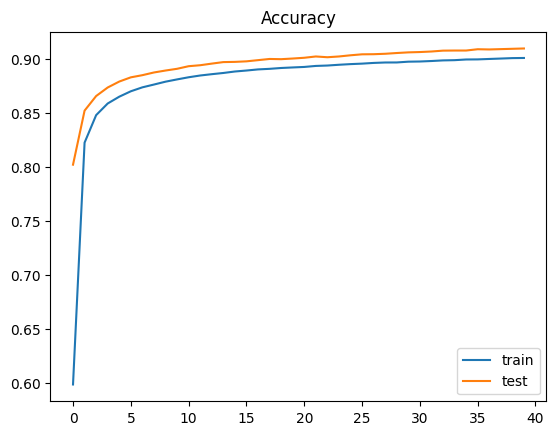

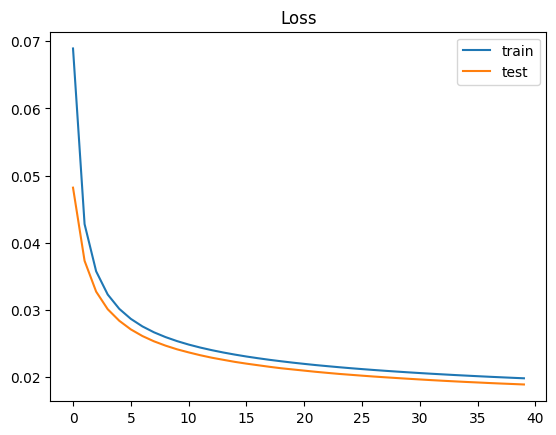

In [17]:
start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 40,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### Quadratic Feature Expansion

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │        15,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,690 (61.29 KB)

 Trainable params: 15,690 (61.29 KB)

 Non-trainable params: 0 (0.00 B)

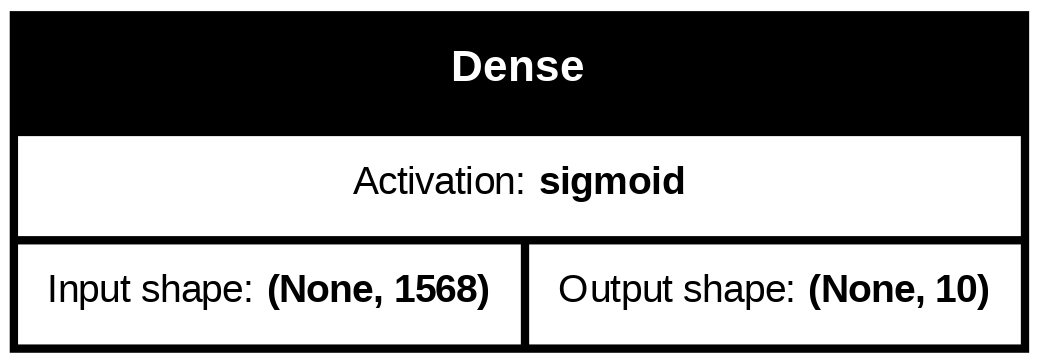

In [18]:
model = logistic_regression(x_train.shape[1]*2, y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.2)
model.compile(optimizer=opt, loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
600/600 - 2s - 4ms/step - accuracy: 0.7103 - loss: 0.0577 - val_accuracy: 0.8437 - val_loss: 0.0388
Epoch 2/40
600/600 - 2s - 3ms/step - accuracy: 0.8470 - loss: 0.0355 - val_accuracy: 0.8656 - val_loss: 0.0314
Epoch 3/40
600/600 - 3s - 4ms/step - accuracy: 0.8619 - loss: 0.0307 - val_accuracy: 0.8768 - val_loss: 0.0282
Epoch 4/40
600/600 - 2s - 4ms/step - accuracy: 0.8702 - loss: 0.0282 - val_accuracy: 0.8817 - val_loss: 0.0264
Epoch 5/40
600/600 - 2s - 3ms/step - accuracy: 0.8748 - loss: 0.0267 - val_accuracy: 0.8869 - val_loss: 0.0252
Epoch 6/40
600/600 - 2s - 3ms/step - accuracy: 0.8795 - loss: 0.0256 - val_accuracy: 0.8902 - val_loss: 0.0242
Epoch 7/40
600/600 - 2s - 3ms/step - accuracy: 0.8827 - loss: 0.0248 - val_accuracy: 0.8925 - val_loss: 0.0235
Epoch 8/40
600/600 - 2s - 3ms/step - accuracy: 0.8853 - loss: 0.0242 - val_accuracy: 0.8935 - val_loss: 0.0229
Epoch 9/40
600/600 - 2s - 3ms/step - accuracy: 0.8874 - loss: 0.0236 - val_accuracy: 0.8962 - val_loss: 0.0224
E

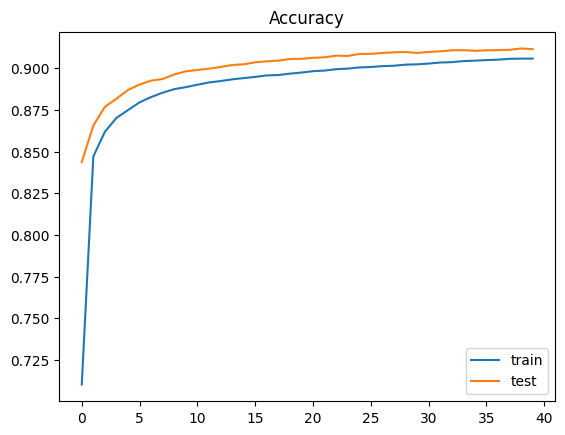

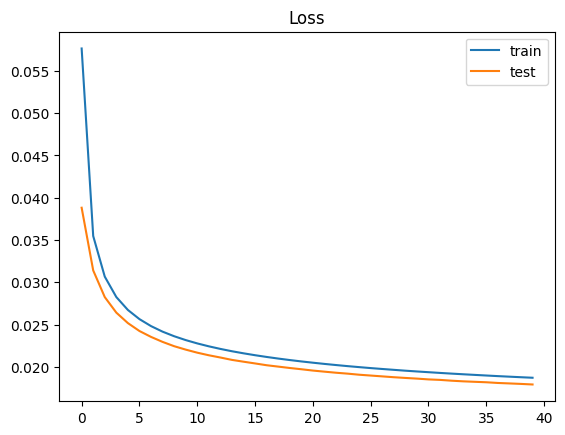

In [19]:
start_train = time.time()
history = model.fit(
    np.hstack((x_train,x_train**2)), y_train,
    epochs =  40,
    batch_size = 100,
    verbose = 2,
    validation_data=(np.hstack((x_test,x_test**2)), y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(np.hstack((x_test,x_test**2)))
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))


### SGD with Momentum

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │        15,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,690 (61.29 KB)

 Trainable params: 15,690 (61.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
600/600 - 4s - 6ms/step - accuracy: 0.7069 - loss: 0.0433 - val_accuracy: 0.8919 - val_loss: 0.0235
Epoch 2/40
600/600 - 4s - 6ms/step - accuracy: 0.8904 - loss: 0.0226 - val_accuracy: 0.9050 - val_loss: 0.0203
Epoch 3/40
600/600 - 2s - 3ms/step - accuracy: 0.8979 - loss: 0.0205 - val_accuracy: 0.9080 - val_loss: 0.0190
Epoch 4/40
600/600 - 2s - 3ms/step - accuracy: 0.9033 - loss: 0.0194 - val_accuracy: 0.9111 - val_loss: 0.0182
Epoch 5/40
600/600 - 2s - 3ms/step - accuracy: 0.9057 - loss: 0.0187 - val_accuracy: 0.9137 - val_loss: 0.0176
Epoch 6/40
600/600 - 3s - 4ms/step - accuracy: 0.9088 - loss: 0.0182 - val_accuracy: 0.9160 - val_loss: 0.0172
Epoch 7/40
600/600 - 2s - 4ms/step - accuracy: 0.9097 - loss: 0.0178 - val_accuracy: 0.9169 - val_loss: 0.0170
Epoch 8/40
600/600 - 2s - 3ms/step - accuracy: 0.9116 - loss: 0.0175 - val_accuracy: 0.9167 - val_loss: 0.0167
Epoch 9/40
600/600 - 2s - 3ms/step - accuracy: 0.9130 - loss: 0.0172 - val_accuracy: 0.9172 - val_loss: 0.0164
E

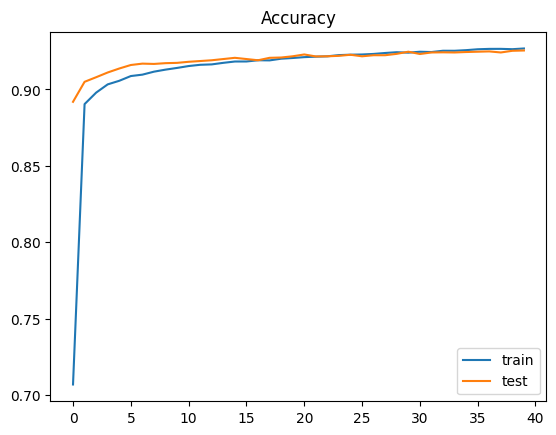

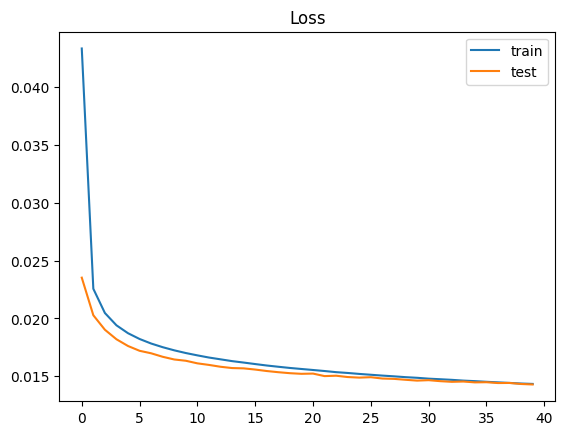

In [20]:
model = logistic_regression(x_train.shape[1]*2, y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.2,momentum=0.9)
model.compile(optimizer=opt, loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    np.hstack((x_train,x_train**2)), y_train,
    epochs =  40,
    batch_size = 100,
    verbose = 2,
    validation_data=(np.hstack((x_test,x_test**2)), y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(np.hstack((x_test,x_test**2)))
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### Adam Optimizer

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │        15,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,690 (61.29 KB)

 Trainable params: 15,690 (61.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
600/600 - 2s - 4ms/step - accuracy: 0.7786 - loss: 0.0403 - val_accuracy: 0.8965 - val_loss: 0.0229
Epoch 2/40
600/600 - 3s - 4ms/step - accuracy: 0.8959 - loss: 0.0216 - val_accuracy: 0.9065 - val_loss: 0.0194
Epoch 3/40
600/600 - 2s - 4ms/step - accuracy: 0.9047 - loss: 0.0193 - val_accuracy: 0.9117 - val_loss: 0.0179
Epoch 4/40
600/600 - 2s - 3ms/step - accuracy: 0.9094 - loss: 0.0181 - val_accuracy: 0.9169 - val_loss: 0.0171
Epoch 5/40
600/600 - 2s - 3ms/step - accuracy: 0.9128 - loss: 0.0173 - val_accuracy: 0.9182 - val_loss: 0.0164
Epoch 6/40
600/600 - 2s - 3ms/step - accuracy: 0.9161 - loss: 0.0167 - val_accuracy: 0.9200 - val_loss: 0.0160
Epoch 7/40
600/600 - 2s - 3ms/step - accuracy: 0.9185 - loss: 0.0163 - val_accuracy: 0.9220 - val_loss: 0.0157
Epoch 8/40
600/600 - 3s - 5ms/step - accuracy: 0.9204 - loss: 0.0159 - val_accuracy: 0.9213 - val_loss: 0.0155
Epoch 9/40
600/600 - 3s - 4ms/step - accuracy: 0.9212 - loss: 0.0156 - val_accuracy: 0.9225 - val_loss: 0.0153
E

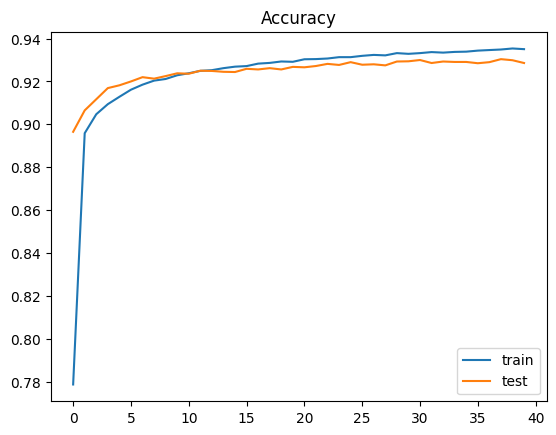

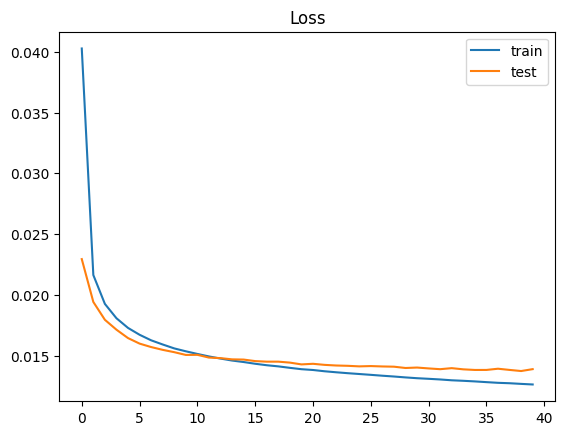

In [21]:
model = logistic_regression(x_train.shape[1]*2, y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.Adam()
model.compile(optimizer=opt, loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    np.hstack((x_train,x_train**2)), y_train,
    epochs =  40,
    batch_size = 100,
    verbose = 2,
    validation_data=(np.hstack((x_test,x_test**2)), y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(np.hstack((x_test,x_test**2)))
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### Cross-Entropy Loss

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │        15,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,690 (61.29 KB)

 Trainable params: 15,690 (61.29 KB)

 Non-trainable params: 0 (0.00 B)

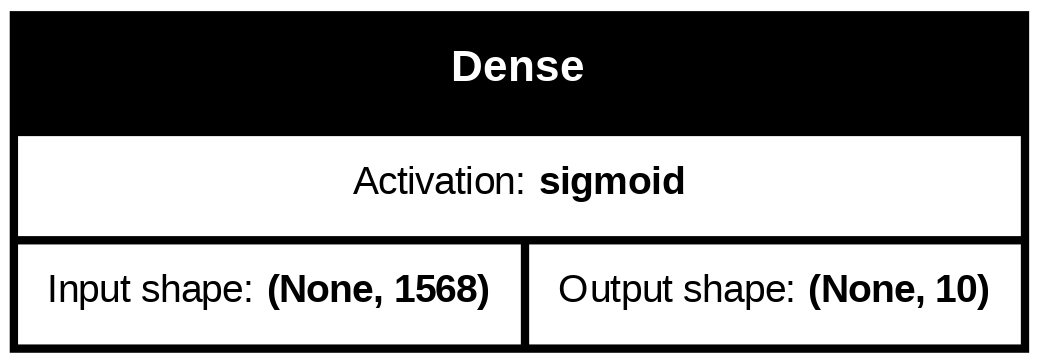

In [22]:
model = logistic_regression(x_train.shape[1]*2, y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.Adam()
model.compile(optimizer=opt, loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
600/600 - 3s - 4ms/step - accuracy: 0.8680 - loss: 0.5051 - val_accuracy: 0.9140 - val_loss: 0.3198
Epoch 2/40
600/600 - 2s - 3ms/step - accuracy: 0.9136 - loss: 0.3138 - val_accuracy: 0.9212 - val_loss: 0.2892
Epoch 3/40
600/600 - 2s - 3ms/step - accuracy: 0.9197 - loss: 0.2895 - val_accuracy: 0.9232 - val_loss: 0.2775
Epoch 4/40
600/600 - 2s - 3ms/step - accuracy: 0.9239 - loss: 0.2777 - val_accuracy: 0.9253 - val_loss: 0.2739
Epoch 5/40
600/600 - 3s - 5ms/step - accuracy: 0.9255 - loss: 0.2700 - val_accuracy: 0.9240 - val_loss: 0.2736
Epoch 6/40
600/600 - 2s - 3ms/step - accuracy: 0.9268 - loss: 0.2642 - val_accuracy: 0.9257 - val_loss: 0.2699
Epoch 7/40
600/600 - 2s - 3ms/step - accuracy: 0.9289 - loss: 0.2593 - val_accuracy: 0.9282 - val_loss: 0.2675
Epoch 8/40
600/600 - 2s - 3ms/step - accuracy: 0.9301 - loss: 0.2553 - val_accuracy: 0.9294 - val_loss: 0.2652
Epoch 9/40
600/600 - 2s - 3ms/step - accuracy: 0.9306 - loss: 0.2519 - val_accuracy: 0.9289 - val_loss: 0.2652
E

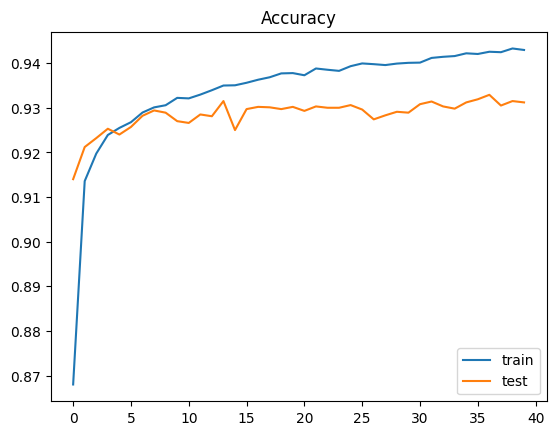

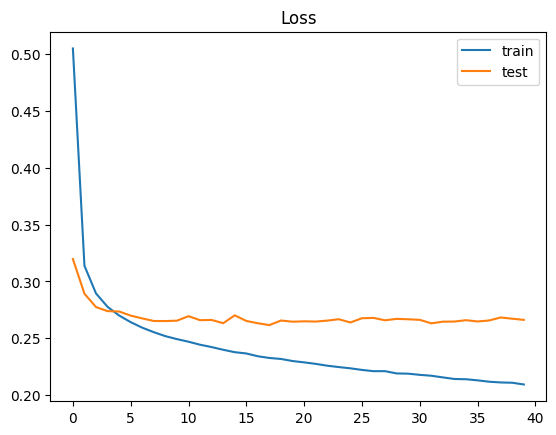

In [23]:
start_train = time.time()
history = model.fit(
    np.hstack((x_train,x_train**2)), y_train,
    epochs =  40,
    batch_size = 100,
    verbose = 2,
    validation_data=(np.hstack((x_test,x_test**2)), y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(np.hstack((x_test,x_test**2)))
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### Softmax Output

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 10)             │        15,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,690 (61.29 KB)

 Trainable params: 15,690 (61.29 KB)

 Non-trainable params: 0 (0.00 B)

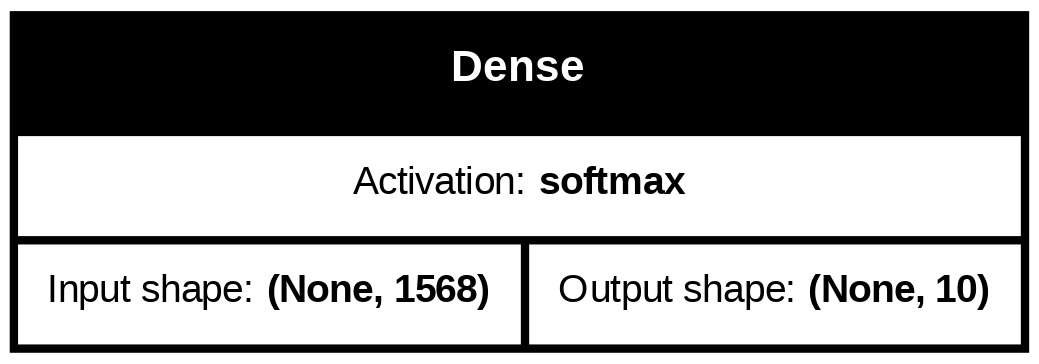

In [24]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Dense(n_outputs, input_shape=(n_inputs,), activation='softmax'))
  return model

model = logistic_regression(x_train.shape[1]*2, y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.Adam()
model.compile(optimizer=opt, loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
600/600 - 3s - 5ms/step - accuracy: 0.8738 - loss: 0.0210 - val_accuracy: 0.9176 - val_loss: 0.0132
Epoch 2/40
600/600 - 5s - 8ms/step - accuracy: 0.9176 - loss: 0.0132 - val_accuracy: 0.9246 - val_loss: 0.0120
Epoch 3/40
600/600 - 2s - 4ms/step - accuracy: 0.9246 - loss: 0.0120 - val_accuracy: 0.9276 - val_loss: 0.0114
Epoch 4/40
600/600 - 2s - 4ms/step - accuracy: 0.9284 - loss: 0.0114 - val_accuracy: 0.9286 - val_loss: 0.0112
Epoch 5/40
600/600 - 2s - 4ms/step - accuracy: 0.9311 - loss: 0.0110 - val_accuracy: 0.9289 - val_loss: 0.0112
Epoch 6/40
600/600 - 4s - 7ms/step - accuracy: 0.9334 - loss: 0.0106 - val_accuracy: 0.9302 - val_loss: 0.0109
Epoch 7/40
600/600 - 2s - 4ms/step - accuracy: 0.9350 - loss: 0.0104 - val_accuracy: 0.9323 - val_loss: 0.0107
Epoch 8/40
600/600 - 2s - 4ms/step - accuracy: 0.9364 - loss: 0.0102 - val_accuracy: 0.9303 - val_loss: 0.0109
Epoch 9/40
600/600 - 3s - 4ms/step - accuracy: 0.9373 - loss: 0.0100 - val_accuracy: 0.9316 - val_loss: 0.0107
E

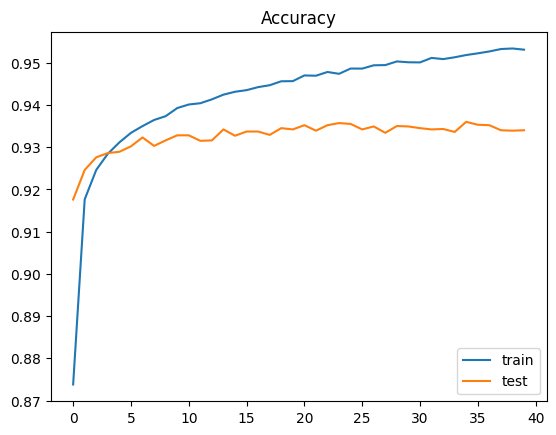

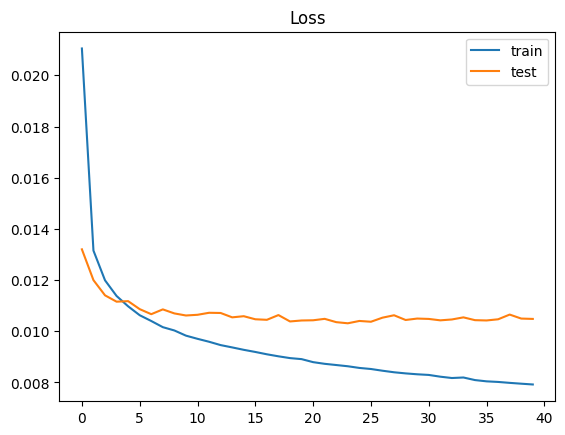

In [25]:
start_train = time.time()
history = model.fit(
    np.hstack((x_train,x_train**2)), y_train,
    epochs =  40,
    batch_size = 100,
    verbose = 2,
    validation_data=(np.hstack((x_test,x_test**2)), y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(np.hstack((x_test,x_test**2)))
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### Softmax with Cross-Entropy

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │        15,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,690 (61.29 KB)

 Trainable params: 15,690 (61.29 KB)

 Non-trainable params: 0 (0.00 B)

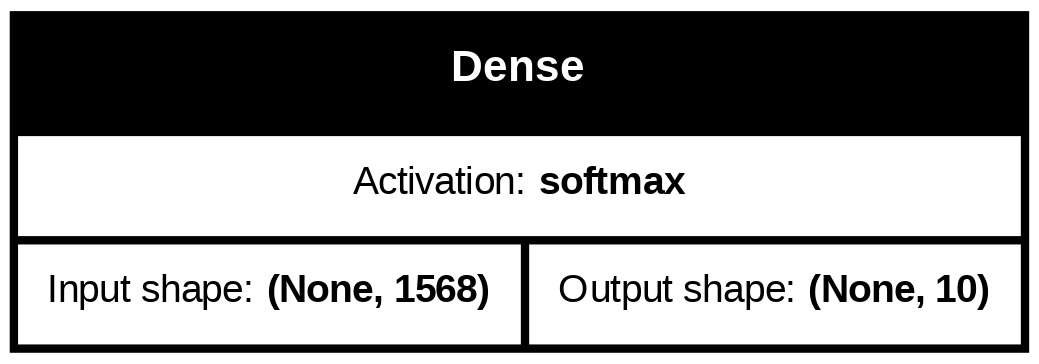

In [26]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Dense(n_outputs, input_shape=(n_inputs,), activation='softmax'))
  return model

model = logistic_regression(x_train.shape[1]*2, y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.Adam()
model.compile(optimizer=opt, loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
600/600 - 4s - 6ms/step - accuracy: 0.8679 - loss: 0.5078 - val_accuracy: 0.9127 - val_loss: 0.3215
Epoch 2/40
600/600 - 3s - 5ms/step - accuracy: 0.9138 - loss: 0.3136 - val_accuracy: 0.9201 - val_loss: 0.2895
Epoch 3/40
600/600 - 3s - 5ms/step - accuracy: 0.9191 - loss: 0.2903 - val_accuracy: 0.9216 - val_loss: 0.2827
Epoch 4/40
600/600 - 2s - 4ms/step - accuracy: 0.9233 - loss: 0.2776 - val_accuracy: 0.9241 - val_loss: 0.2738
Epoch 5/40
600/600 - 2s - 4ms/step - accuracy: 0.9247 - loss: 0.2708 - val_accuracy: 0.9238 - val_loss: 0.2778
Epoch 6/40
600/600 - 2s - 4ms/step - accuracy: 0.9275 - loss: 0.2636 - val_accuracy: 0.9274 - val_loss: 0.2717
Epoch 7/40
600/600 - 2s - 4ms/step - accuracy: 0.9290 - loss: 0.2599 - val_accuracy: 0.9271 - val_loss: 0.2663
Epoch 8/40
600/600 - 4s - 6ms/step - accuracy: 0.9310 - loss: 0.2553 - val_accuracy: 0.9258 - val_loss: 0.2713
Epoch 9/40
600/600 - 2s - 4ms/step - accuracy: 0.9311 - loss: 0.2526 - val_accuracy: 0.9280 - val_loss: 0.2680
E

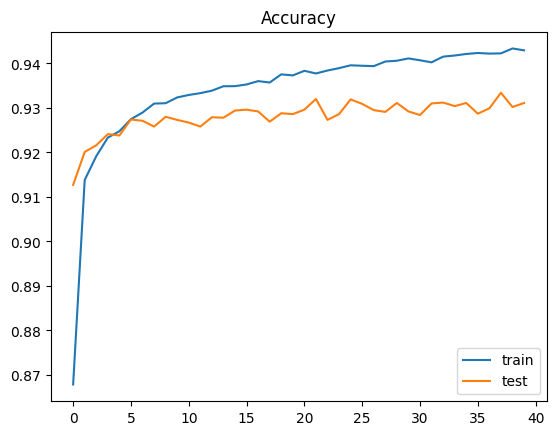

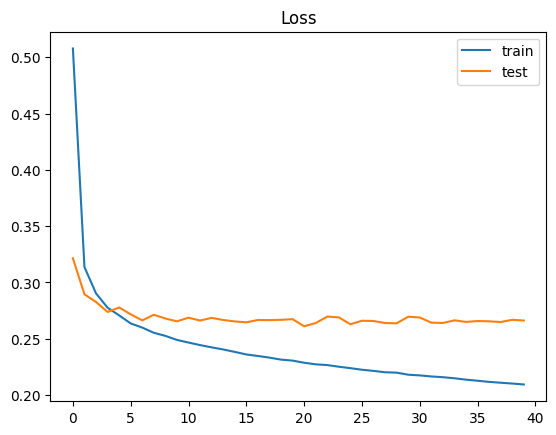

In [27]:
start_train = time.time()
history = model.fit(
    np.hstack((x_train,x_train**2)), y_train,
    epochs =  40,
    batch_size = 100,
    verbose = 2,
    validation_data=(np.hstack((x_test,x_test**2)), y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(np.hstack((x_test,x_test**2)))
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

### SGD with Momentum, Softmax, and Categorical Cross-Entropy

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10)             │        15,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,690 (61.29 KB)

 Trainable params: 15,690 (61.29 KB)

 Non-trainable params: 0 (0.00 B)

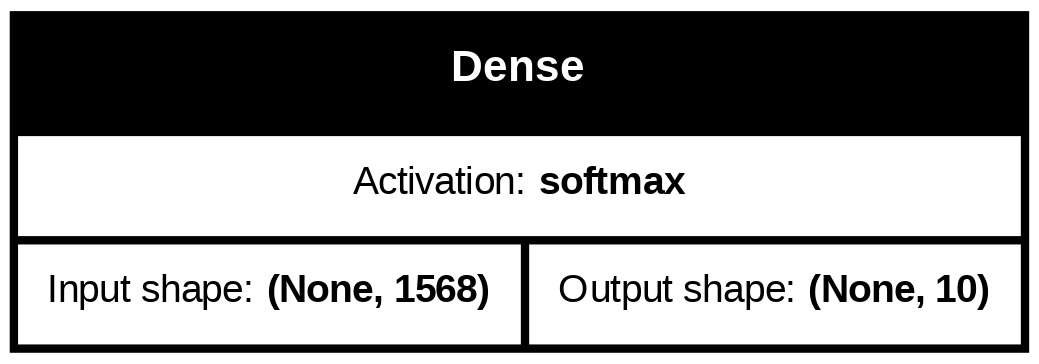

In [28]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Dense(n_outputs, input_shape=(n_inputs,), activation='softmax'))
  return model

model = logistic_regression(x_train.shape[1]*2, y_train.shape[1])
model.summary()
opt = tf.keras.optimizers.SGD(learning_rate=0.001,momentum=0.9)
model.compile(optimizer=opt, loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

Epoch 1/40
600/600 - 3s - 5ms/step - accuracy: 0.7709 - loss: 0.9652 - val_accuracy: 0.8648 - val_loss: 0.5803
Epoch 2/40
600/600 - 2s - 4ms/step - accuracy: 0.8656 - loss: 0.5377 - val_accuracy: 0.8837 - val_loss: 0.4656
Epoch 3/40
600/600 - 3s - 5ms/step - accuracy: 0.8792 - loss: 0.4637 - val_accuracy: 0.8903 - val_loss: 0.4199
Epoch 4/40
600/600 - 3s - 5ms/step - accuracy: 0.8863 - loss: 0.4275 - val_accuracy: 0.8956 - val_loss: 0.3929
Epoch 5/40
600/600 - 2s - 4ms/step - accuracy: 0.8916 - loss: 0.4047 - val_accuracy: 0.8998 - val_loss: 0.3753
Epoch 6/40
600/600 - 2s - 4ms/step - accuracy: 0.8945 - loss: 0.3886 - val_accuracy: 0.9027 - val_loss: 0.3627
Epoch 7/40
600/600 - 2s - 4ms/step - accuracy: 0.8974 - loss: 0.3767 - val_accuracy: 0.9048 - val_loss: 0.3527
Epoch 8/40
600/600 - 2s - 3ms/step - accuracy: 0.8997 - loss: 0.3670 - val_accuracy: 0.9065 - val_loss: 0.3452
Epoch 9/40
600/600 - 4s - 6ms/step - accuracy: 0.9017 - loss: 0.3593 - val_accuracy: 0.9071 - val_loss: 0.3392
E

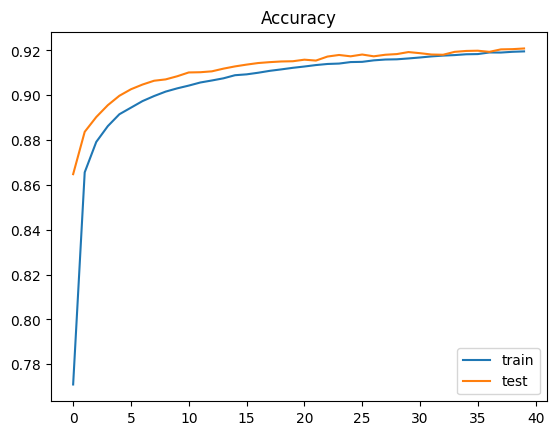

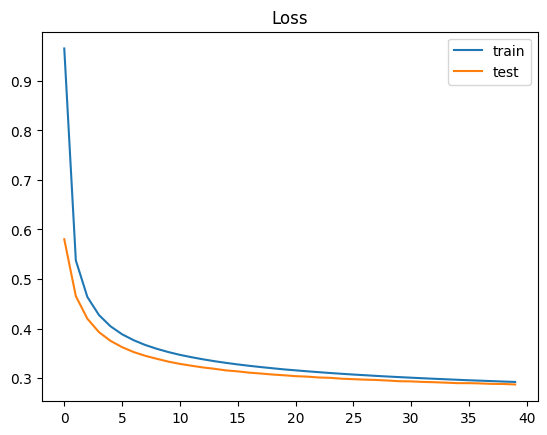

In [29]:
start_train = time.time()
history = model.fit(
    np.hstack((x_train,x_train**2)), y_train,
    epochs =  40,
    batch_size = 100,
    verbose = 2,
    validation_data=(np.hstack((x_test,x_test**2)), y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(np.hstack((x_test,x_test**2)))
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.3f}'.format(mean_absolute_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(pred_int,np.argmax(y_test,axis=1))))
print('Confusion matrix')
print(confusion_matrix(np.argmax(y_test,axis=1), pred_int))

## 3. Modeling Progression

The experiments in this notebook provide a controlled progression:

1. Manual linear classification
2. Manual logistic regression
3. scikit-learn logistic regression
4. TensorFlow linear model
5. Quadratic feature expansion
6. Sigmoid logistic model
7. SGD with momentum
8. Adam
9. Cross-entropy
10. Softmax
11. Softmax with categorical cross-entropy
12. SGD with momentum + softmax + categorical cross-entropy